# 7 Recurrent neural networks
In this exercise we will try a simple experiment with a recurrent neural network. One of the well-known recurrent neural network models is the so called Long short-term memory (LSTM) network. More information on LSTM can be found in the text [Understanding LSTM Networks](http://colah.github.io/posts/2015-08-Understanding-LSTMs/).

## 7.1 The MNIST dataset revisited (1)
In one of the previous exercises the MNIST dataset was used to demonstrate the use of multilayer perceptron. Here we are going to apply a recurrent neural network to the problem of digits classification. To keep it simple, we will use a simple LSTM network that will be fed with one row of the image at a time. With each new row, it will update its states and give its prediction. What we are interested in is its prediction after the last row i.e. after it has the full information.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import pandas as pd

In [1]:

# Constants
learning_rate = 0.001
num_epochs = 10
batch_size = 100
# we will feed a row at a time to the LSTM and there are 28 rows per image
timesteps = 28
# each row has 28 columns whose values are simultaneously passed to LSTM
n_input = 28 # MNIST data input (img shape: 28*28)
# the number of hidden states in the LSTM
n_hidden = 128
n_classes = 10

# Data transformation
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Initialize the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(n_input, n_hidden, 1, n_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.view(-1, timesteps, n_input).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Test the model
    if (epoch + 1) % 1 == 0:
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in test_loader:
                images = images.view(-1, timesteps, n_input).to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            print(f'Epoch [{epoch + 1}/{num_epochs}], Test Accuracy: {accuracy:.2f}%')

Epoch [1/10], Test Accuracy: 96.54%
Epoch [2/10], Test Accuracy: 97.53%
Epoch [3/10], Test Accuracy: 98.04%
Epoch [4/10], Test Accuracy: 98.42%
Epoch [5/10], Test Accuracy: 98.36%
Epoch [6/10], Test Accuracy: 98.60%
Epoch [7/10], Test Accuracy: 98.65%
Epoch [8/10], Test Accuracy: 98.70%
Epoch [9/10], Test Accuracy: 98.72%
Epoch [10/10], Test Accuracy: 98.84%


**Tasks**

1. Study and run the code above.
2. Draw a plot that shows the relation between the number of rows given to the network and its final accuracy on the test set.
3. What happens if we use gradient descent instead of Adam? The accuracy is noticably lowered.


Text(0, 0.5, 'test accuracy')

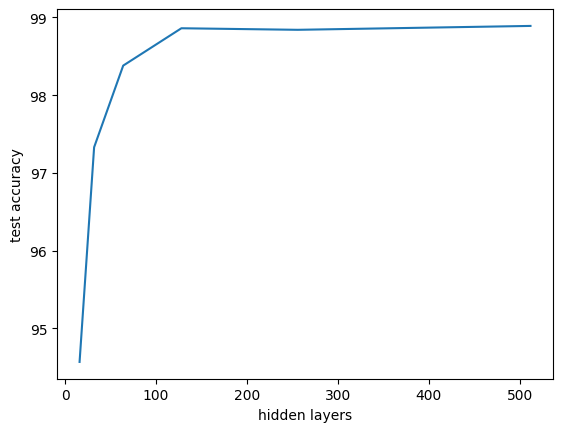

In [7]:
import matplotlib.pyplot as plt

learning_rate = 0.001
num_epochs = 10
batch_size = 100
# we will feed a row at a time to the LSTM and there are 28 rows per image
timesteps = 28
# each row has 28 columns whose values are simultaneously passed to LSTM
n_input = 28 # MNIST data input (img shape: 28*28)
# the number of hidden states in the LSTM
n_hidden = 128
n_classes = 10

acc_log = []

for n_hidden in [16, 32, 64, 128, 256, 512]:
    model = LSTMModel(n_input, n_hidden, 1, n_classes).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    total_step = len(train_loader)
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.view(-1, timesteps, n_input).to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch == num_epochs-1:
            with torch.no_grad():
                correct = 0
                total = 0
                for images, labels in test_loader:
                    images = images.view(-1, timesteps, n_input).to(device)
                    labels = labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                accuracy = 100 * correct / total
                acc_log.append(accuracy)
            
plt.plot([16, 32, 64, 128, 256, 512], acc_log)
plt.xlabel("hidden layers")
plt.ylabel("test accuracy")

Text(0, 0.5, 'test accuracy')

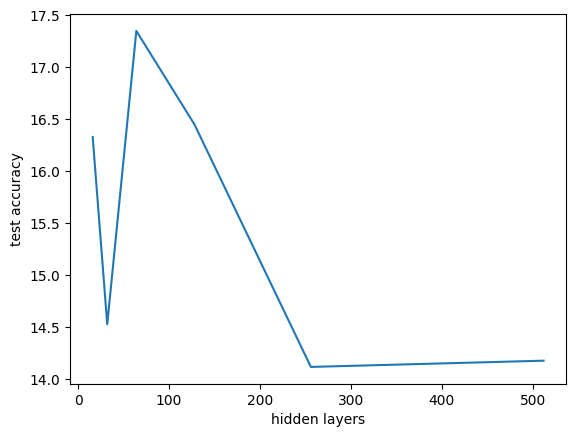

In [8]:
import matplotlib.pyplot as plt

learning_rate = 0.001
num_epochs = 10
batch_size = 100
# we will feed a row at a time to the LSTM and there are 28 rows per image
timesteps = 28
# each row has 28 columns whose values are simultaneously passed to LSTM
n_input = 28 # MNIST data input (img shape: 28*28)
# the number of hidden states in the LSTM
n_hidden = 128
n_classes = 10

acc_log = []

for n_hidden in [16, 32, 64, 128, 256, 512]:
    model = LSTMModel(n_input, n_hidden, 1, n_classes).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Training loop
    total_step = len(train_loader)
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.view(-1, timesteps, n_input).to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch == num_epochs-1:
            with torch.no_grad():
                correct = 0
                total = 0
                for images, labels in test_loader:
                    images = images.view(-1, timesteps, n_input).to(device)
                    labels = labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                accuracy = 100 * correct / total
                acc_log.append(accuracy)
            
plt.plot([16, 32, 64, 128, 256, 512], acc_log)
plt.xlabel("hidden layers")
plt.ylabel("test accuracy")

# 8 Convolutional neural networks


The goal of this exercise is to learn the basic stuff about [convolutional neural networks](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN or ConvNet). In the previous exercises, the building blocks mostly included simple operations that had some kind of activations functions and each layer was usually fully connected to the previous one. CNNs take into account the spatial nature of the input data, e.g. an image, and they process it by applying one or more  [kernels](https://en.wikipedia.org/wiki/Kernel_%28image_processing%29). In the case of images, this processing i.e. convolving is also known as filtering. The results of processing the input with a single kernel will be a single channel, but usually a convolutional layer involves more kernels producing more channels. These channels are often called **feature maps** because each kernel is specialized for extraction of a certain kind of features from the input. These feature maps are then combined into a single tensor that can be viewed as an image with multiple channels that can be then passed to further convolutional layers.

For example, if the input consists of a grayscale image i.e. an image with only one channel and a $5\times 5$ kernel is applied, the result is a single feature map. The borders of the input image are usually padded with zeros to ensure that the resulting feature maps has the same number of rows and columns as the input image.

If the input consists of a color image i.e. an image with three channels and a $5\times 5$ kernel is applied, what will actually be applied is an $5\times 5\times 3$ kernel that will simultaneously process all three channels and the result will again be a single feature map. However, if e.g. 16 several kernels are applied, then the result will be 16 feature maps. Should they be passed to another convolutional layer, **each** of its kernels would simultaneously process **all** feature maps so their sizes would be e.g. $3\times 3\times 16$ or $5\times 5\times 16$ where 16 is used to reach all feature maps simultaneously.

The convolution is usually followed by applying an element-wise non-linear operation to each of the values in the feature maps. Finally, what often follows is the summarization i.e. pooling of the information in the feature maps to reduce the spatial dimensions and keep only the most important information. A common approach used here is the so called max pooling. It is a non-linear downsampling where the input is divided into a set of non-overlapping rectangles and for each of them only the maximum value inside of it is kept.

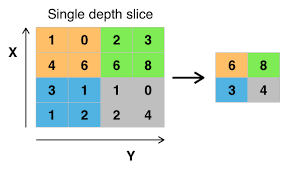
<center>Figure 1. Max pooling with $2\times 2$ rectangles (taken from [Wikipedia](https://en.wikipedia.org/wiki/File:Max_pooling.png)).</center>

What usually follows after several convolutional layers is putting the values of all feature maps into a single vector, which is then passed further to fully connected or other kinds of layers.

The number of parameters in the convolutional depends on the number of feature maps and the sizes of the kernels. For example, if a convolutional layer with 32 kernels of nominal size $3\times 3$ receives 16 feature maps on its input, it will require $16\times 3\times 3\times 32+32$ where the last 32 parameters refer to the kernel biases.

### Google Colab preliminaries

Upload the zipped cnn_img folder to Google Colab and ensure the paths in the notebook are adjusted accordingly.

If the notebook is not run on Google Colab, skip the following commands.

In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [ ]:
# !unzip /content/cnn_img.zip

## 8.1 The MNIST dataset revisited (2)
In one of the previous exercises the MNIST dataset was used to demonstrate the use of multilayer perceptron. Here we are going to apply a convolutional neural network to the digit classification problem. We will use the following layers to build our model:

* [torch.nn.ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU)
* [torch.nn.Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
* [torch.nn.MaxPool2d](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d)
* [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear)

The [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear) layer has the same effect as the fully connected layer, a matrix multiplication that was used in the previous exercise with the MNIST dataset.

**Tasks**

1. Study and run the code below. How is the accuracy compared to the ones obtained in the previous exerises with MNIST? The accuracy is higher, but not much better than the MLP
2. Try to change the number and size of convolutional and fully connected layers. What has the greatest impact on the accuracy? For each network architecture configuration calculate the number of trainable parameters. The best performing model was one with 2 convolutional layer and one fully connected. The size of the number of layers seem to have the most impact, because the worst performing model had the most layers.
3. What happens to the accuracy if another [non-linearity](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) is used instead of ReLU? Experiment with at least two different activation functions. I used the Sigmoid and LeakyReLU, both improved the final accuracy

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import tqdm

In [33]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_fully_connected,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu2 = nn.ReLU()

    self.maxpool2 = nn.MaxPool2d((2,2))

    self.fc1 = nn.Linear(in_features=7*7*n_channels_2, out_features=n_fully_connected, bias=True)

    self.relu3 = nn.ReLU()

    self.fc2 = nn.Linear(in_features=n_fully_connected, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.relu2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.relu3(x)
    
    # Non-linearity
    pred_logits = self.fc2(x)
    
    return pred_logits


In [19]:
def train_epoch(model, device, train_dataloader, optimizer, epoch):

    model.train()

    train_loss = 0.0

#     for batch in tqdm.tqdm(train_dataloader):

      # Every data instance is an input image + label pair
#       images, labels = batch
    for images, labels in train_dataloader:

      # It is necessary to have both the model, and the data on the same device, either CPU or GPU, for the model to process data.
      # Data on CPU and model on GPU, or vice-versa, will result in a Runtime error.
      images, labels = images.to(device), labels.to(device)

      # Zero your gradients for every batch
      optimizer.zero_grad()

      # Make predictions for this batch
      pred_logits = model(images)

      # Compute the loss
      loss = loss_fn(pred_logits, labels)

      # Calculates the backward gradients over the learning weights
      loss.backward()

      # Tells the optimizer to perform one learning step
      # Adjust the model�s learning weights based on the observed gradients for this batch
      optimizer.step()

      train_loss += loss.item()

    # Print epoch's average loss
#     print("Epoch {} - Training loss: {}".format(epoch+1, train_loss/len(train_dataloader)))


def evaluation(model, device, test_dataloader, epoch):

    # Sets layers like dropout and batch normalization to evaluation mode before running inference
    # Failing to do this will yield inconsistent inference results
    model.eval()

    test_accuracy = 0.0

    # Disabling gradient calculation is useful for inference, when you are sure that you will not call Tensor.backward().
    # It will reduce memory consumption for computations that would otherwise have requires_grad=True.
    with torch.no_grad():

#       for batch in tqdm.tqdm(test_dataloader):

#         images, labels = batch
        for images, labels in test_dataloader:

            images, labels = images.to(device), labels.to(device)

            pred_logits = model(images)

            probabilities = torch.nn.functional.softmax(pred_logits, dim=1)

            # Find the index of the highest probability
            predictions = probabilities.argmax(dim=1)

            # Caluculate average batch accuracy
            batch_accuracy = torch.mean((predictions == labels).float())

            test_accuracy += batch_accuracy

    return test_accuracy/len(test_dataloader)
#      print("Epoch {} - Accuracy: {}".format(epoch+1, test_accuracy/len(test_dataloader)))




In [20]:
# Architecture configs
input_channels=1
n_channels_1=32
n_channels_2=64
n_classes=10
n_fully_connected=128
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

# Model
# model = CNN(input_channels, n_channels_1, n_channels_2, n_fully_connected, n_classes, kernel_size)

# Move model to GPU if possible
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# Augmentations
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])

# Stores the samples and their corresponding labels
train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('../data', train=False, transform=transform)

# Wraps an iterable around the Dataset to enable easy access to the samples.
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [21]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training
for epoch in range(training_epochs_count):

  train_epoch(model, device, train_dataloader, optimizer, epoch)

  if (epoch + 1) % display_step == 0:

    evaluation(model, device, test_dataloader, epoch)



# Vary the sizes of layers

In [6]:
import pandas as pd
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "n_channels_2", "n_fully_connected", "acc"])

for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [32, 64, 128]:
        for n_fully_connected in [64, 128, 256]:
            # Model
            model = CNN(input_channels, n_channels_1, n_channels_2, n_fully_connected, n_classes, kernel_size)

            # Move model to GPU if possible
            device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
            model.to(device)

            # Define loss function
            loss_fn = nn.CrossEntropyLoss()

            # Define optimizer
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

            for epoch in range(training_epochs_count):

              train_epoch(model, device, train_dataloader, optimizer, epoch)

              if epoch == training_epochs_count-1:

                acc = evaluation(model, device, test_dataloader, epoch)
                df.loc[len(df)] = [n_channels_1, n_channels_2, n_fully_connected, float(acc)]

df.to_csv("2conv_2fc.csv")

In [37]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [32, 64, 128]:
        for n_fully_connected in [64, 128, 256]:
            model = CNN(input_channels, n_channels_1, n_channels_2, n_fully_connected, n_classes, kernel_size)
            param_sum = 0
            for p in model.parameters():
                param_multiplier=1
                for dim in p.shape:
                    param_multiplier *= dim

                param_sum += param_multiplier

            param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range 114314 to 1815050


# 2 convolutional 1 fully connected

In [38]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu2 = nn.ReLU()

    self.maxpool2 = nn.MaxPool2d((2,2))

    self.fc1 = nn.Linear(in_features=7*7*n_channels_2, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.relu2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    pred_logits = self.fc1(x)
    
    
    return pred_logits


In [39]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [32, 64, 128]:
        model = CNN(input_channels, n_channels_1, n_channels_2, n_classes, kernel_size)
        param_sum = 0
        for p in model.parameters():
            param_multiplier=1
            for dim in p.shape:
                param_multiplier *= dim

            param_sum += param_multiplier

        param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range from 28938 to 269322


In [29]:
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "n_channels_2", "acc"])

for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [32, 64, 128]:
            # Model
            model = CNN(input_channels, n_channels_1, n_channels_2, n_classes, kernel_size)

            # Move model to GPU if possible
            device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
            model.to(device)

            # Define loss function
            loss_fn = nn.CrossEntropyLoss()

            # Define optimizer
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

            for epoch in range(training_epochs_count):

              train_epoch(model, device, train_dataloader, optimizer, epoch)

              if epoch == training_epochs_count-1:

                acc = evaluation(model, device, test_dataloader, epoch)
                df.loc[len(df)] = [n_channels_1, n_channels_2, float(acc)]

df.to_csv("2conv_1fc.csv")

KeyboardInterrupt: 

# 1 convolutional 2 fully connected

In [40]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_fully_connected,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))


    self.fc1 = nn.Linear(in_features=14*14*n_channels_1, out_features=n_fully_connected, bias=True)

    self.relu3 = nn.ReLU()

    self.fc2 = nn.Linear(in_features=n_fully_connected, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.relu3(x)
    
    # Non-linearity
    pred_logits = self.fc2(x)
    
    return pred_logits


In [46]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    for n_fully_connected in [64, 128, 256]:
        model = CNN(input_channels, n_channels_1, n_fully_connected, n_classes, kernel_size)
        param_sum = 0
        for p in model.parameters():
            param_multiplier=1
            for dim in p.shape:
                param_multiplier *= dim

            param_sum += param_multiplier

        param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range from 201834 to 3215754


In [19]:
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "n_fully_connected", "acc"])

for n_channels_1 in [16, 32, 64]:
        for n_fully_connected in [64, 128, 256]:
            # Model
            model = CNN(input_channels, n_channels_1, n_fully_connected, n_classes, kernel_size)

            # Move model to GPU if possible
            device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
            model.to(device)

            # Define loss function
            loss_fn = nn.CrossEntropyLoss()

            # Define optimizer
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

            for epoch in range(training_epochs_count):

              train_epoch(model, device, train_dataloader, optimizer, epoch)

              if epoch == training_epochs_count-1:

                acc = evaluation(model, device, test_dataloader, epoch)
                df.loc[len(df)] = [n_channels_1, n_fully_connected, float(acc)]

df.to_csv("1conv_2fc.csv")

# 1 convolutional 1 fully connected

In [47]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))


    self.fc1 = nn.Linear(in_features=14*14*n_channels_1, out_features=n_classes, bias=True)


  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Non-linearity
    pred_logits = self.fc1(x)
    
    return pred_logits


In [48]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    model = CNN(input_channels, n_channels_1, n_classes, kernel_size)
    param_sum = 0
    for p in model.parameters():
        param_multiplier=1
        for dim in p.shape:
            param_multiplier *= dim

        param_sum += param_multiplier

    param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range from 31786 to 127114


In [22]:
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "acc"])

for n_channels_1 in [16, 32, 64]:
            # Model
            model = CNN(input_channels, n_channels_1, n_classes, kernel_size)

            # Move model to GPU if possible
            device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
            model.to(device)

            # Define loss function
            loss_fn = nn.CrossEntropyLoss()

            # Define optimizer
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

            for epoch in range(training_epochs_count):

              train_epoch(model, device, train_dataloader, optimizer, epoch)

              if epoch == training_epochs_count-1:

                acc = evaluation(model, device, test_dataloader, epoch)
                df.loc[len(df)] = [n_channels_1, float(acc)]

df.to_csv("1conv_1fc.csv")

# 3 convolutional 2 fully connected

In [50]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_channels_3,
               n_fully_connected,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu2 = nn.ReLU()

    self.maxpool2 = nn.MaxPool2d((2,2))
    
    self.conv3 = nn.Conv2d(in_channels=n_channels_2,
                           out_channels=n_channels_3,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu3 = nn.ReLU()

    self.maxpool3 = nn.MaxPool2d((2,2))

    self.fc1 = nn.Linear(in_features=3*3*n_channels_3, out_features=n_fully_connected, bias=True)

    self.relu3 = nn.ReLU()

    self.fc2 = nn.Linear(in_features=n_fully_connected, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.relu2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    x = self.conv3(x)
    
    # again, we apply the non-linearity
    x = self.relu3(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool3(x)
#     print(x.shape)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.relu3(x)
    
    # Non-linearity
    pred_logits = self.fc2(x)
    
    return pred_logits


In [51]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [16, 32, 64]:
        for n_channels_3 in [16, 32, 64]:
            for n_fully_connected in [64, 128, 256]:
                # Model
                model = CNN(input_channels, n_channels_1, n_channels_2, n_channels_3, n_fully_connected, n_classes, kernel_size)
                param_sum = 0
                for p in model.parameters():
                    param_multiplier=1
                    for dim in p.shape:
                        param_multiplier *= dim

                    param_sum += param_multiplier

                param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range from 23178 to 356874


In [30]:
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "n_channels_2", "n_channels_3", "n_fully_connected", "acc"])

for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [16, 32, 64]:
        for n_channels_3 in [16, 32, 64]:
            for n_fully_connected in [64, 128, 256]:
                # Model
                model = CNN(input_channels, n_channels_1, n_channels_2, n_channels_3, n_fully_connected, n_classes, kernel_size)

                # Move model to GPU if possible
                device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
                model.to(device)

                # Define loss function
                loss_fn = nn.CrossEntropyLoss()

                # Define optimizer
                optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

                for epoch in range(training_epochs_count):

                  train_epoch(model, device, train_dataloader, optimizer, epoch)

                  if epoch == training_epochs_count-1:

                    acc = evaluation(model, device, test_dataloader, epoch)
                    df.loc[len(df)] = [n_channels_1, n_channels_2, n_channels_3, n_fully_connected, float(acc)]

df.to_csv("3conv_2fc.csv")

# 2 convolutional 3 fully connected

In [19]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_fc_1,
               n_fc_2,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu2 = nn.ReLU()

    self.maxpool2 = nn.MaxPool2d((2,2))
    
    self.fc1 = nn.Linear(in_features=7*7*n_channels_2, out_features=n_fc_1, bias=True)

    self.relu3 = nn.ReLU()

    self.fc2 = nn.Linear(in_features=n_fc_1, out_features=n_fc_2, bias=True)
    
    self.relu4 = nn.ReLU()
    
    self.fc3 = nn.Linear(in_features=n_fc_2, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.relu2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.relu3(x)
    
    # Non-linearity
    x = self.fc2(x)
    
    x = self.relu4(x)
    
    pred_logits = self.fc3(x)
    
    return pred_logits


In [52]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [16, 32, 64]:
            for n_fc_1 in [64, 128, 256]:
                for n_fc_2 in [64, 128, 256]:
                    # Model
                    model = CNN(input_channels, n_channels_1, n_channels_2, n_fc_1, n_fc_2, n_classes, kernel_size)
                param_sum = 0
                for p in model.parameters():
                    param_multiplier=1
                    for dim in p.shape:
                        param_multiplier *= dim

                    param_sum += param_multiplier

                param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range from 182778 to 1106634


In [20]:
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "n_channels_2", "n_fc_1", "n_fc_2", "acc"])

for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [16, 32, 64]:
            for n_fc_1 in [64, 128, 256]:
                for n_fc_2 in [64, 128, 256]:
                    # Model
                    model = CNN(input_channels, n_channels_1, n_channels_2, n_fc_1, n_fc_2, n_classes, kernel_size)

                    # Move model to GPU if possible
                    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
                    model.to(device)

                    # Define loss function
                    loss_fn = nn.CrossEntropyLoss()

                    # Define optimizer
                    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

                    for epoch in range(training_epochs_count):

                      train_epoch(model, device, train_dataloader, optimizer, epoch)

                      if epoch == training_epochs_count-1:

                        acc = evaluation(model, device, test_dataloader, epoch)
                        df.loc[len(df)] = [n_channels_1, n_channels_2, n_fc_1, n_fc_2, float(acc)]

df.to_csv("2conv_3fc.csv")

AttributeError: 'CNN' object has no attribute 'conv3'

# 3 convolutional 3 fully connected

In [53]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_channels_3,
               n_fc_1,
               n_fc_2,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu1 = nn.ReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu2 = nn.ReLU()

    self.maxpool2 = nn.MaxPool2d((2,2))
    
    self.conv3 = nn.Conv2d(in_channels=n_channels_2,
                           out_channels=n_channels_3,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.relu3 = nn.ReLU()

    self.maxpool3 = nn.MaxPool2d((2,2))
    
    self.fc1 = nn.Linear(in_features=3*3*n_channels_3, out_features=n_fc_1, bias=True)

    self.relu3 = nn.ReLU()

    self.fc2 = nn.Linear(in_features=n_fc_1, out_features=n_fc_2, bias=True)
    
    self.relu4 = nn.ReLU()
    
    self.fc3 = nn.Linear(in_features=n_fc_2, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.relu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.relu2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    x = self.conv3(x)
    
    # again, we apply the non-linearity
    x = self.relu3(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool3(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.relu3(x)
    
    # Non-linearity
    x = self.fc2(x)
    
    x = self.relu4(x)
    
    pred_logits = self.fc3(x)
    
    return pred_logits


In [54]:
param_array = []
for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [16, 32, 64]:
        for n_channels_3 in [16, 32, 64]:
                for n_fc_1 in [64, 128, 256]:
                    for n_fc_2 in [64, 128, 256]:
                        # Model
                        model = CNN(input_channels, n_channels_1, n_channels_2, n_channels_3, n_fc_1, n_fc_2, n_classes, kernel_size)
                        param_sum = 0
                        for p in model.parameters():
                            param_multiplier=1
                            for dim in p.shape:
                                param_multiplier *= dim

                            param_sum += param_multiplier

                        param_array.append(param_sum)
        
print(f"the number of parameters is in range from {min(param_array)} to {max(param_array)}")

the number of parameters is in range from 27338 to 422666


In [22]:
# Architecture configs
input_channels=1
n_classes=10
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1

df = pd.DataFrame([], columns=["n_channels_1", "n_channels_2", "n_channels_3", "n_fc_1", "n_fc_2", "acc"])

for n_channels_1 in [16, 32, 64]:
    for n_channels_2 in [16, 32, 64]:
        for n_channels_3 in [16, 32, 64]:
                for n_fc_1 in [64, 128, 256]:
                    for n_fc_2 in [64, 128, 256]:
                        # Model
                        model = CNN(input_channels, n_channels_1, n_channels_2, n_channels_3, n_fc_1, n_fc_2, n_classes, kernel_size)

                        # Move model to GPU if possible
                        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
                        model.to(device)

                        # Define loss function
                        loss_fn = nn.CrossEntropyLoss()

                        # Define optimizer
                        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

                        for epoch in range(training_epochs_count):

                          train_epoch(model, device, train_dataloader, optimizer, epoch)

                          if epoch == training_epochs_count-1:

                            acc = evaluation(model, device, test_dataloader, epoch)
                            df.loc[len(df)] = [n_channels_1, n_channels_2, n_channels_3, n_fc_1, n_fc_2, float(acc)]

df.to_csv("3conv_3fc.csv")

In [13]:
for conv, fc in [(1, 1), (1,2), (2, 1), (2, 2), (2, 3), (3, 2), (3, 3)]:
    df = pd.read_csv(f"{conv}conv_{fc}fc.csv", index_col=0)
    print(df.sort_values(by="acc").head())


   n_channels_1       acc
0          16.0  0.984176
1          32.0  0.984873
2          64.0  0.985470
   n_channels_1  n_fully_connected       acc
8          64.0              256.0  0.985271
3          32.0               64.0  0.986266
4          32.0              128.0  0.986266
2          16.0              256.0  0.986365
1          16.0              128.0  0.986664
   n_channels_1  n_channels_2       acc
6          64.0          32.0  0.988754
0          16.0          32.0  0.990247
8          64.0         128.0  0.990346
3          32.0          32.0  0.990446
4          32.0          64.0  0.990943
    n_channels_1  n_channels_2  n_fully_connected       acc
6           16.0         128.0               64.0  0.987560
26          64.0         128.0              256.0  0.987659
2           16.0          32.0              256.0  0.987759
13          32.0          64.0              128.0  0.987958
1           16.0          32.0              128.0  0.988854
    n_channels_1  n_channe

# different non-linearity

In [59]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_fully_connected,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.sigm1 = nn.Sigmoid()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.sigm2 = nn.Sigmoid()

    self.maxpool2 = nn.MaxPool2d((2,2))

    self.fc1 = nn.Linear(in_features=7*7*n_channels_2, out_features=n_fully_connected, bias=True)

    self.sigm3 = nn.Sigmoid()

    self.fc2 = nn.Linear(in_features=n_fully_connected, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.sigm1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.sigm2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.sigm3(x)
    
    # Non-linearity
    pred_logits = self.fc2(x)
    
    return pred_logits


In [61]:
# Architecture configs
input_channels=1
n_channels_1=32
n_channels_2=64
n_classes=10
n_fully_connected=128
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1
loss_fn = nn.CrossEntropyLoss()

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training
for epoch in range(training_epochs_count):

  train_epoch(model, device, train_dataloader, optimizer, epoch)


print(f"final accuracy is {evaluation(model, device, test_dataloader, epoch)}")

final accuracy is 0.9915406107902527


In [63]:
class CNN(nn.Module):

  # Method that defines the layers and other components of a model
  def __init__(self,
               input_channels,
               n_channels_1,
               n_channels_2,
               n_fully_connected,
               n_classes,
               kernel_size
               ):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=input_channels,
                           out_channels=n_channels_1,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.lrelu1 = nn.LeakyReLU()

    self.maxpool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(in_channels=n_channels_1,
                           out_channels=n_channels_2,
                           kernel_size=kernel_size,
                           padding='same'
                           )

    self.lrelu2 = nn.LeakyReLU()

    self.maxpool2 = nn.MaxPool2d((2,2))

    self.fc1 = nn.Linear(in_features=7*7*n_channels_2, out_features=n_fully_connected, bias=True)

    self.lrelu3 = nn.LeakyReLU()

    self.fc2 = nn.Linear(in_features=n_fully_connected, out_features=n_classes, bias=True)

  # Method where the computation gets done
  def forward(self, x):

    # First convolutional layer
    # We will apply n_channels_1 kernels of size kernel_size X kernel_size
    # We are padding the input in order for the result to have the same number of rows and columns
    x = self.conv1(x)

    # Applying the non-linearity
    x = self.lrelu1(x)
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool1(x)
    
    # Second convolutional layer
    # We will apply n_channels_2 kernels of size kernel_size X kernel_size
    x = self.conv2(x)
    
    # again, we apply the non-linearity
    x = self.lrelu2(x)
    
    # and max pooling again, now each feature map will be of size 7 X 7
    x = self.maxpool2(x)
    
    # Flatten all dimensions except the batch
    x = torch.flatten(x, 1)
    
    # Fully connected layer
    x = self.fc1(x)
    
    # and again, we apply the non-linearity
    x = self.lrelu3(x)
    
    # Non-linearity
    pred_logits = self.fc2(x)
    
    return pred_logits


In [64]:
# Architecture configs
input_channels=1
n_channels_1=32
n_channels_2=64
n_classes=10
n_fully_connected=128
kernel_size=5

# Training configs
training_epochs_count = 5
batch_size = 64
learning_rate = 0.001
display_step=1
loss_fn = nn.CrossEntropyLoss()

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training
for epoch in range(training_epochs_count):

  train_epoch(model, device, train_dataloader, optimizer, epoch)


print(f"final accuracy is {evaluation(model, device, test_dataloader, epoch)}")

final accuracy is 0.9921377301216125


## 8.2 Image classification
Image classification is a challenging computer vision problem with the best-known competition being [The ImageNet Large Scale Visual Recognition Challenge (ILSVRC)](http://www.image-net.org/challenges/LSVRC/), which includes the ImageNet dataset with millions of $224\times 224$ training images. The class names in one of the tasks there can be found [here](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a). One of the most important breakthroughs was when in 2012 the convolutional neural network [AlexNet](https://en.wikipedia.org/wiki/AlexNet) won the first place. Ever since many highly successful convolutional neural networks architectures have been proposed, e.g. [VGG-16](https://arxiv.org/abs/1409.1556), [VGG-19](https://arxiv.org/abs/1409.1556), [ResNet](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf), [Inception](https://arxiv.org/abs/1409.4842), etc. Training such networks requires a lot of time because they have many layers with millions of parameters. In this exercise we are going to experiment with pre-trained models of some of the best known architectures.

### 8.2.1 Using pre-trained models
Try running the following code:

In [33]:
import torchvision.models as models
from torchvision.io import read_image

### Choose the architecture
architecture="resnet34"
# architecture="vgg16"
# architecture="vgg19"
# architecture="inceptionv3"

if architecture == "resnet34":
  weights = models.ResNet34_Weights.DEFAULT
  model = models.resnet34(weights=weights)
elif architecture == "vgg16":
  weights = models.VGG16_Weights.DEFAULT
  model = models.vgg16(pretrained=weights)
elif architecture == "vgg19":
  weights = models.VGG19_Weights.DEFAULT
  model = models.vgg19(pretrained=weights)
elif architecture == "inceptionv3":
  weights = models.Inception_V3_Weights.DEFAULT
  model = models.inception_v3(pretrained=weights)

model.eval()

image_paths=["cnn_img/badger.jpg", "cnn_img/rabbit.jpg", "cnn_img/sundial.jpg", "cnn_img/pineapple.jpg", "cnn_img/can.jpg"]

for path in image_paths:
    #loading the image and rescaling it to fit the size for the imagenet architectures
    img = read_image(path)
    preprocess = weights.transforms(antialias=True)
    batch = preprocess(img).unsqueeze(0)

    prediction = model(batch).squeeze(0).softmax(0)
    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = weights.meta["categories"][class_id]

    print(f"{category_name}: {100 * score:.1f}%")

badger: 99.5%
wood rabbit: 89.4%
sundial: 100.0%
pineapple: 100.0%
table lamp: 38.9%


In [34]:
image_paths=["cnn_img/healthy/87.jpg",
             "cnn_img/healthy/23.jpg",
             "cnn_img/healthy/60.jpg",
             "cnn_img/unhealthy/87.jpg",
             "cnn_img/unhealthy/20.jpg",
             "cnn_img/unhealthy/13.jpg",
            ]


for path in image_paths:
    #loading the image and rescaling it to fit the size for the imagenet architectures
    img = read_image(path)
    preprocess = weights.transforms(antialias=True)
    batch = preprocess(img).unsqueeze(0)

    prediction = model(batch).squeeze(0).softmax(0)
    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = weights.meta["categories"][class_id]

    print(f"{category_name}: {100 * score:.1f}%")

bell pepper: 40.6%
hot pot: 25.6%
hamper: 39.6%
pizza: 98.3%
cheeseburger: 59.9%
cheeseburger: 52.0%


**Tasks**
1. Is there any significant difference between the results of different architectures? I see no significant difference between architectures.
2. Try to classify several other images from the folders cnn_img/healthy and cnn_img/unhealthy that you choose on your own. Which cases are problematic? The problematic are cases with different types of food in the same image, and also if they have contrasting colors.

### 8.2.2 Creating your own classifier - pincers vs. scissors
Although ImageNet has a lot of classes, sometimes they do not cover some desired cases. Let's assume that we want to tell images with pincers apart from the ones with scissors. Neither pincers nor scissors are among ImageNet classes. Nevertheless, we can still use some parts of the pre-trained models.

Various layers of a deep convolutional network have diferent tasks. The ones closest to the original input image usually look for features such as edges and corners i.e. for low-level features. After them there are layers that look for middle-level features such as circular objects, special curves, etc. Next, there are usually fully connected layers that create high-level semantic features by combining the information from the previous layers. These features are then used by the last layer that performs the actual classification. What we can do here is simply to discard the last layer i.e. not to calculate the class of an image, but to extract the values in on of the fully connected layers. This effectively means that we are going to use the network only as an extractor for high-level features that we would hardly be able to engineer on our own. Let's first see which layers can be found in the ResNet network:

In [87]:
import torchvision.models as models
import numpy as np

architecture="vgg16"

if architecture == "resnet34":
  weights = models.ResNet34_Weights.DEFAULT
  base_model = models.resnet34(weights=weights)
elif architecture == "resnet50":
  weights = models.ResNet50_Weights.DEFAULT
  base_model = models.resnet50(weights=weights)
elif architecture == "vgg16":
  weights = models.VGG16_Weights.DEFAULT
  base_model = models.vgg16(weights=weights)

for layer in base_model.children():
    print(layer)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

At the end you can see fully connected layer used for classification. We can extract the values from previous layers by using the following code:

In [88]:
# Model without last fully connected layer
model = torch.nn.Sequential(*(list(base_model.children())[:-1]), nn.AdaptiveAvgPool2d(1))

img_path="cnn_img/rabbit.jpg"

img = read_image(img_path)
preprocess = weights.transforms(antialias=True)
batch = preprocess(img).unsqueeze(0)

features = model(batch).squeeze(3).squeeze(2)

print(features.shape)
feature_layer_size=features.shape[1];

torch.Size([1, 512])


These values can now be used as features and that can later be used with another classifier. Let's first extract the features for our pincer and scissors images.

In [121]:
def create_numbered_paths(home_dir, n):
    return [home_dir+str(i)+".jpg" for i in range(n)]

def create_paired_numbered_paths(first_home_dir, second_home_dir, n):
    image_paths=[]
    for p in zip(create_numbered_paths(first_home_dir, n), create_numbered_paths(second_home_dir, n)):
        image_paths.extend(p)
        
    return image_paths

def create_features(paths, verbose=False):
    n=len(paths)
    features=np.zeros((n, feature_layer_size))
    for i in range(n):
        if (verbose==True):
            print("\t%2d / %2d"%(i+1, n))
        img = read_image(paths[i])
        preprocess = weights.transforms(antialias=True)
        batch = preprocess(img).unsqueeze(0)
        features[i, :]=model(batch).squeeze(3).squeeze(2).detach().numpy()

    return features

pincers_dir="cnn_img/pincers/"
scissors_dir="cnn_img/scissors/"

individual_n=50

#combining all image paths
image_paths=create_paired_numbered_paths(pincers_dir, scissors_dir, individual_n)

#marking their classes
image_classes=[]
for i in range(individual_n):
    #0 stands for the pincer image and 0 stands for the scissors image
    image_classes.extend((0, 1))

#number of all images
n=100
#number of training images
n_train=50
#number of test images
n_test=n-n_train

print("Creating training features...")
#here we will store the features of training images
x_train=create_features(image_paths[:n_train])
#train classes
y_train=np.array(image_classes[:n_train])

print("Creating test features...")
#here we will store the features of test images
x_test=create_features(image_paths[n_train:])

#train classes
y_test=np.array(image_classes[n_train:])

Creating training features...
Creating test features...


Now that for each image we have its features, we will divide the images into a training and a test set. Then we will use a linear SVM classifier to classify them.

In [43]:
from sklearn import svm

def create_svm_classifier(x, y, C=1.0, kernel='linear'):
    #we will use linear SVM
    classifier=svm.SVC(kernel=kernel, C=C);
    classifier.fit(x, y)
    return classifier

def calculate_accuracy(classifier, x, y):
    predicted=classifier.predict(x)
    return np.sum(y==predicted)/y.size

In [71]:
#training the model
classifier=create_svm_classifier(x_train, y_train, 1.0, "poly")

#checking the model's accuracy
print("Accuracy: %.2lf%%"%(100*calculate_accuracy(classifier, x_test, y_test)))

Accuracy: 98.00%


**Tasks**

1. Is there any significant gain if more complex SVM models are used? A rbf kernel gives 2% more accuracy. An increase in the C parameter doesn't improve the result.
2. What happens if we extract features using different backbone, e.g. vgg16? vgg16 backbone gives 100% accuracy with linear and rbf kernel


### 8.2.1 Creating your own classifier - healthy vs. unhealthy food
The previous example was relatively simple because all images were of same size and each of them had a white background, which allowed the extractor to concentrate only on the features of the actual objects. In this example we will use a slightly more complicated case - namely, will will tell images with healthy food apart from the ones with unhealthy food. FIrst let's repeat the same process as we did in the previous example and create the features:

In [122]:
healthy_dir="cnn_img/healthy/"
unhealthy_dir="cnn_img/unhealthy/"

individual_n=100

#combining all image paths
image_paths=create_paired_numbered_paths(healthy_dir, unhealthy_dir, individual_n)

#marking their classes
image_classes=[]
for i in range(individual_n):
    #0 stands for the pincer image and 0 stands for the scissors image
    image_classes.extend((0, 1))

#number of all images
n=200
#number of training images
n_train=100
#number of test images
n_test=n-n_train

print("Creating training features...")
#here we will store the features of training images
x_train=create_features(image_paths[:n_train])
#train classes
y_train=np.array(image_classes[:n_train])

print("Creating test features...")
#here we will store the features of test images
x_test=create_features(image_paths[n_train:])
#train classes
y_test=np.array(image_classes[n_train:])

Creating training features...
Creating test features...


Now let's train a model and test its accuracy:

In [90]:
classifier=create_svm_classifier(x_train, y_train, 1.0, "linear")
print("Accuracy: %.2lf%%"%(100*calculate_accuracy(classifier, x_test, y_test)))

Accuracy: 92.00%


In [119]:
problem_examples = []
predicted=classifier.predict(x_test)
hitmap = y_test!=predicted
        
test_im_paths = pd.Series(image_paths[n_train:])

test_im_paths[hitmap]

36      cnn_img/healthy/68.jpg
38      cnn_img/healthy/69.jpg
46      cnn_img/healthy/73.jpg
52      cnn_img/healthy/76.jpg
76      cnn_img/healthy/88.jpg
81    cnn_img/unhealthy/90.jpg
83    cnn_img/unhealthy/91.jpg
98      cnn_img/healthy/99.jpg
dtype: object

**Tasks**
1. Try the whole food classification with another network as a feature extractor and compare their results. vgg16 is once again the best feature extractor.
2. What kind of test images are problematic? The problematic images are once again the ones that contain multible different food items and different colours at that.